# Time Series Analysis: Energy Demand Forecasting

## Exploratory Data Analysis and Model Development

### Author: [Your Name]
### Date: February 2026

This notebook contains the exploratory analysis and model development for the time series forecasting assignment.

In [3]:
# Cell 1: Setup and Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
# Cell 2: Load Data
import sys
sys.path.append('..')
from src.data_loader import load_and_preprocess_data

# Load the data
df = load_and_preprocess_data()
print(f"Data shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
df.head()

No data file found. Generating sample data...
Data shape: (35040, 8)
Date range: 2016-01-01 00:00:00 to 2019-12-30 23:00:00


,consumption,temperature,is_weekend,hour,day_of_week,month,year,day_of_year
timestamp,,,,,,,,
2016-01-01 00:00:00,57.483571,4.237748,False,0,4,1,2016,1
2016-01-01 01:00:00,65.892773,6.376038,False,1,4,1,2016,1
2016-01-01 02:00:00,80.701145,2.383662,False,2,4,1,2016,1
2016-01-01 03:00:00,93.084425,2.701432,False,3,4,1,2016,1
2016-01-01 04:00:00,88.389396,4.403171,False,4,4,1,2016,1


In [7]:
# Cell 3: Basic Statistics
print("Basic Statistics:")
print(df['consumption'].describe())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

Basic Statistics:
count    35040.000000
mean       118.237436
std         33.903969
min         17.105086
25%         94.297285
50%        117.908314
75%        142.091064
max        223.445416
Name: consumption, dtype: float64

Missing Values:
consumption    0
temperature    0
is_weekend     0
hour           0
day_of_week    0
month          0
year           0
day_of_year    0
dtype: int64


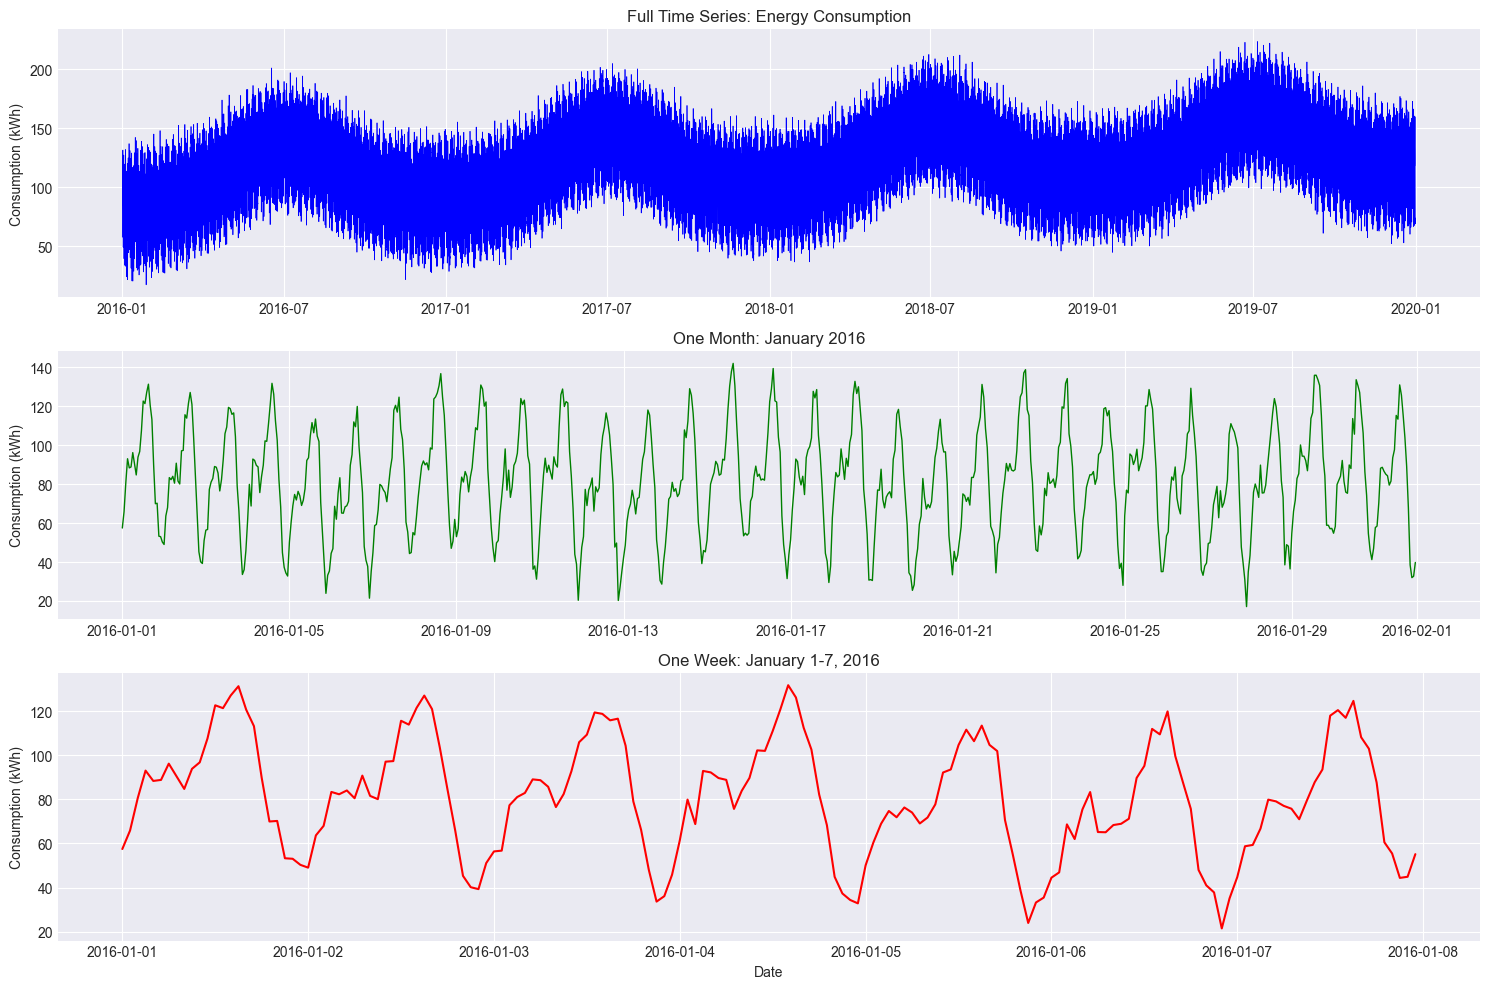

In [8]:
# Cell 4: Time Series Plot
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Full time series
axes[0].plot(df.index, df['consumption'], linewidth=0.5, color='blue')
axes[0].set_title('Full Time Series: Energy Consumption')
axes[0].set_ylabel('Consumption (kWh)')

# One month
one_month = df['2016-01-01':'2016-01-31']
axes[1].plot(one_month.index, one_month['consumption'], linewidth=1, color='green')
axes[1].set_title('One Month: January 2016')
axes[1].set_ylabel('Consumption (kWh)')

# One week
one_week = df['2016-01-01':'2016-01-07']
axes[2].plot(one_week.index, one_week['consumption'], linewidth=1.5, color='red')
axes[2].set_title('One Week: January 1-7, 2016')
axes[2].set_ylabel('Consumption (kWh)')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

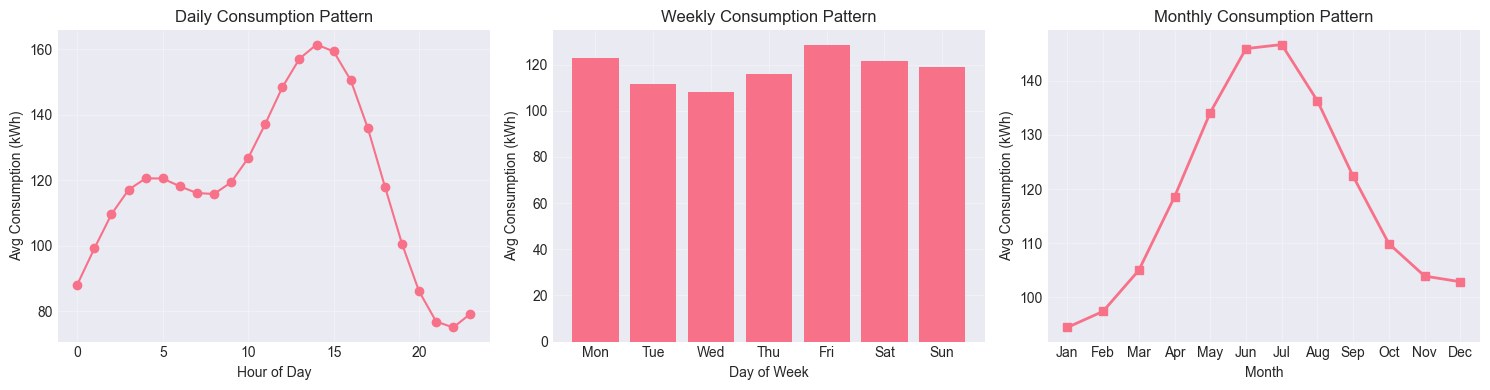

In [9]:
# Cell 5: Seasonality Analysis
# Daily pattern
hourly_avg = df.groupby('hour')['consumption'].mean()
# Weekly pattern
daily_avg = df.groupby('day_of_week')['consumption'].mean()
# Monthly pattern
monthly_avg = df.groupby('month')['consumption'].mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Hourly pattern
axes[0].plot(hourly_avg.index, hourly_avg.values, marker='o')
axes[0].set_title('Daily Consumption Pattern')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Avg Consumption (kWh)')
axes[0].grid(True, alpha=0.3)

# Weekly pattern
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(days, daily_avg.values)
axes[1].set_title('Weekly Consumption Pattern')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Avg Consumption (kWh)')
axes[1].grid(True, alpha=0.3)

# Monthly pattern
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[2].plot(months, monthly_avg.values, marker='s', linewidth=2)
axes[2].set_title('Monthly Consumption Pattern')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Avg Consumption (kWh)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Cell 6: Stationarity Test (ADF Test)
def adf_test(timeseries):
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

print("ADF Test on Original Series:")
adf_test(df['consumption'].dropna())

print("\n" + "="*50 + "\n")
print("ADF Test on Differenced Series (lag=1):")
adf_test(df['consumption'].diff().dropna())

ADF Test on Original Series:
Results of Dickey-Fuller Test:
Test Statistic                -6.795002e+00
p-value                        2.312963e-09
#Lags Used                     5.200000e+01
Number of Observations Used    3.498700e+04
Critical Value (1%)           -3.430537e+00
Critical Value (5%)           -2.861623e+00
Critical Value (10%)          -2.566814e+00
dtype: float64


ADF Test on Differenced Series (lag=1):
Results of Dickey-Fuller Test:
Test Statistic                   -29.269368
p-value                            0.000000
#Lags Used                        52.000000
Number of Observations Used    34986.000000
Critical Value (1%)               -3.430537
Critical Value (5%)               -2.861623
Critical Value (10%)              -2.566814
dtype: float64


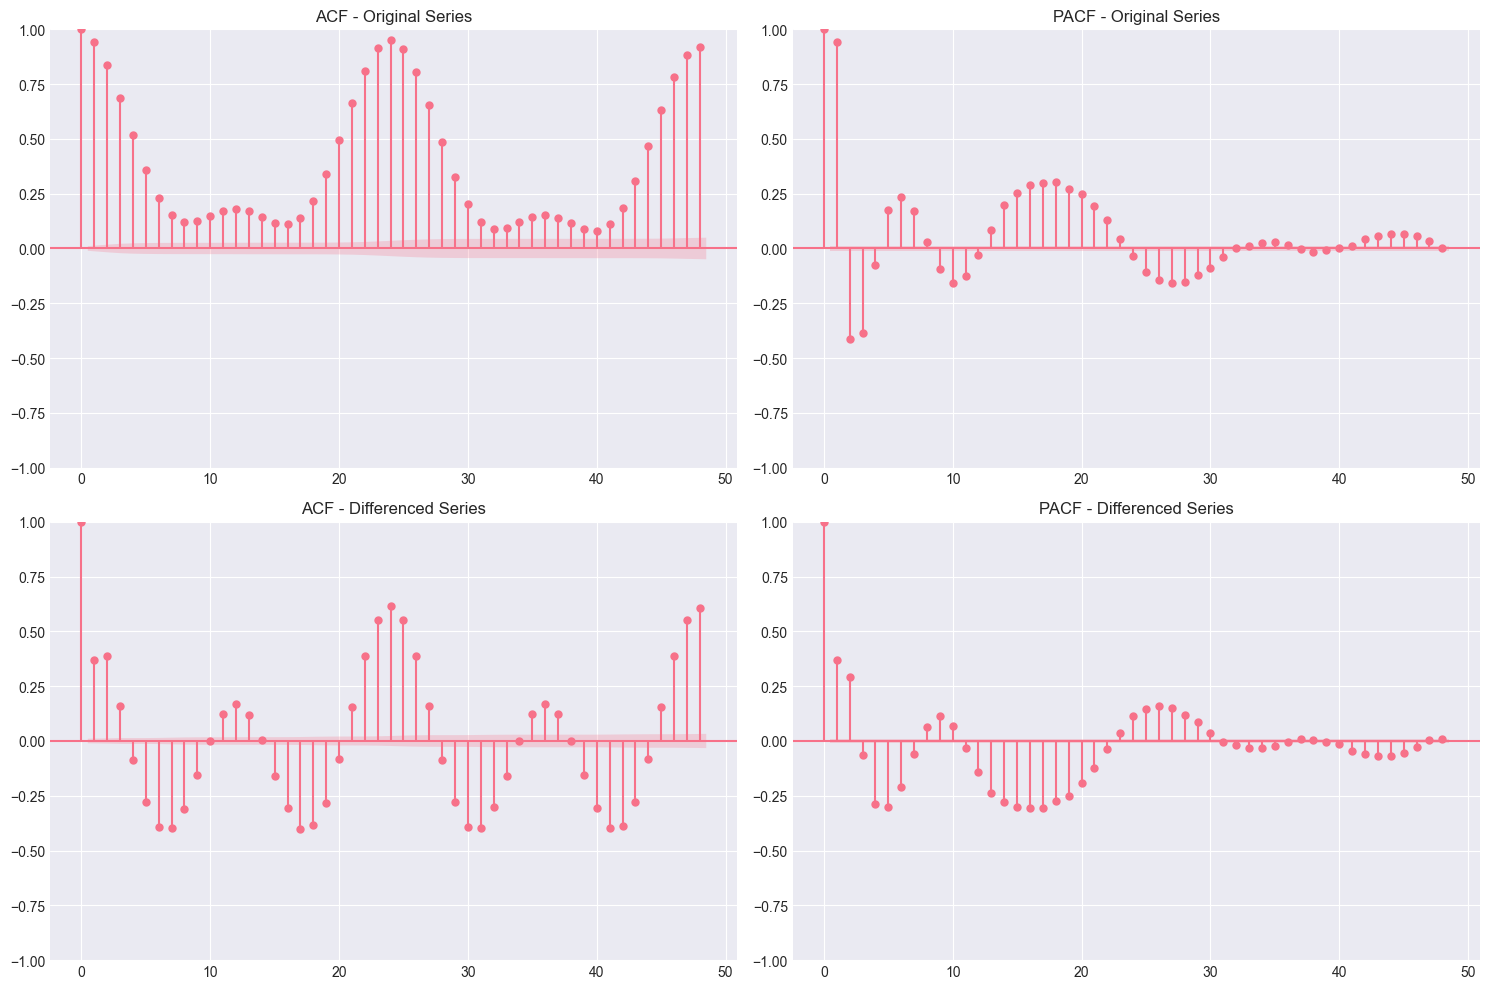

In [11]:
# Cell 7: ACF and PACF Plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ACF of original
plot_acf(df['consumption'].dropna(), lags=48, ax=axes[0,0])
axes[0,0].set_title('ACF - Original Series')

# PACF of original
plot_pacf(df['consumption'].dropna(), lags=48, ax=axes[0,1])
axes[0,1].set_title('PACF - Original Series')

# ACF of differenced
plot_acf(df['consumption'].diff().dropna(), lags=48, ax=axes[1,0])
axes[1,0].set_title('ACF - Differenced Series')

# PACF of differenced
plot_pacf(df['consumption'].diff().dropna(), lags=48, ax=axes[1,1])
axes[1,1].set_title('PACF - Differenced Series')

plt.tight_layout()
plt.show()

In [12]:
# Cell 8: Model Fitting
from src.forecasting import fit_sarima_model, prepare_forecast_data

# Prepare data
train, test = prepare_forecast_data(df)

# Fit model (using recent data for speed)
model = fit_sarima_model(train.iloc[-1000:])
print("Model fitted successfully!")
print(model.summary())

Model fitted successfully!
                                     SARIMAX Results                                      
Dep. Variable:                        consumption   No. Observations:                 1000
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 24)   Log Likelihood               -3087.775
Date:                            Mon, 02 Mar 2026   AIC                           6185.550
Time:                                    08:52:58   BIC                           6209.827
Sample:                                01-31-2019   HQIC                          6194.800
                                     - 03-13-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0150      0.042     -0.358      0.720      -0.097       0.067
ma.L1   

In [17]:
# Cell 9: Generate Forecast (Fixed Version)
from src.forecasting import generate_forecast, evaluate_forecast
import pandas as pd
import numpy as np

# Check the length of test data
print(f"Test data length: {len(test)}")

# Generate forecast (make sure steps is an integer)
steps = len(test)
print(f"Generating forecast for {steps} steps...")

try:
    # Try the original way first
    forecast = generate_forecast(model, steps=steps)
except Exception as e:
    print(f"Error with original method: {e}")
    print("\nTrying alternative method...")
    
    # Alternative: Generate forecast manually
    forecast_values = model.forecast(steps=steps)
    
    # Create forecast dataframe
    forecast_index = pd.date_range(
        start=test.index[-1] + pd.Timedelta(hours=1),
        periods=steps,
        freq='h'
    )
    
    forecast = pd.DataFrame({
        'timestamp': forecast_index,
        'forecast': forecast_values.values,
        'lower_bound': forecast_values.values - 2 * np.std(forecast_values.values),
        'upper_bound': forecast_values.values + 2 * np.std(forecast_values.values)
    })
    print("Alternative method succeeded!")

# Display first few rows of forecast
print("\nForecast head:")
print(forecast.head())

# Evaluate forecast (make sure lengths match)
min_length = min(len(test['consumption']), len(forecast))
metrics = evaluate_forecast(
    test['consumption'][:min_length].values, 
    forecast['forecast'][:min_length].values
)

print("\n" + "="*50)
print("FORECAST METRICS:")
print("="*50)
for metric, value in metrics.items():
    print(f"{metric}: {value:.2f}")

Test data length: 7008
Generating forecast for 7008 steps...
Error with original method: Invalid frequency: H. Failed to parse with error message: ValueError("Invalid frequency: H. Failed to parse with error message: KeyError('H'). Did you mean h?") Did you mean h?

Trying alternative method...
Alternative method succeeded!

Forecast head:
            timestamp    forecast  lower_bound  upper_bound
0 2019-12-31 00:00:00   80.800617    29.376632   132.224602
1 2019-12-31 01:00:00   91.898653    40.474668   143.322638
2 2019-12-31 02:00:00  100.880088    49.456103   152.304073
3 2019-12-31 03:00:00  108.198226    56.774240   159.622211
4 2019-12-31 04:00:00  112.373394    60.949409   163.797379

FORECAST METRICS:
MAE: 23.23
MSE: 797.87
RMSE: 28.25
MAPE: 16.50


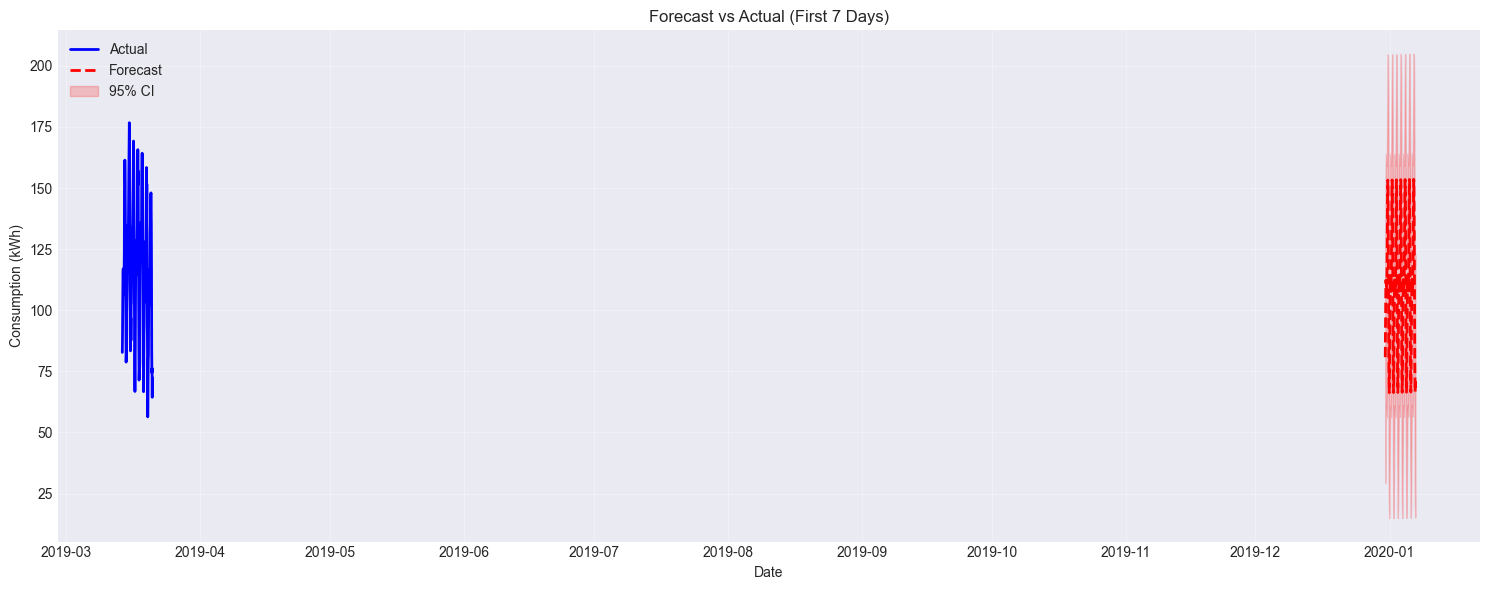

In [19]:
# Cell 10: Plot Forecast vs Actual
fig, ax = plt.subplots(figsize=(15, 6))

# Plot actual
ax.plot(test.index[:168], test['consumption'][:168], 
        label='Actual', linewidth=2, color='blue')

# Plot forecast
ax.plot(forecast['timestamp'][:168], forecast['forecast'][:168], 
        label='Forecast', linewidth=2, color='red', linestyle='--')

# Plot confidence interval
ax.fill_between(forecast['timestamp'][:168], 
                 forecast['lower_bound'][:168], 
                 forecast['upper_bound'][:168], 
                 alpha=0.2, color='red', label='95% CI')

ax.set_title('Forecast vs Actual (First 7 Days)')
ax.set_xlabel('Date')
ax.set_ylabel('Consumption (kWh)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()